# Undersampling Analysis: MAGeCK RRA vs. Z-score Method (Drepanos et al.)

## Rationale
Pooled CRISPR viability screens are vulnerable to **bottlenecking**: a loss of
library representation that occurs when a screen passes through a stage with too
few cells (e.g. low viral titer, harsh selection pressure, poor recovery). Under a
bottleneck, only a random subset of guides is captured in the readout by chance,
inflating variance in guide-level read counts independent of any true gene
phenotype. Because this noise is stochastic and gene-agnostic, a well-calibrated
statistical method should not call large numbers of genes significant from
bottlenecking alone.

This notebook simulates a bottlenecked screen by comparing a randomly selected single screen well
against a randomly selected single pDNA well and evaluates
whether three statistical methods stay appropriately calibrated under that noise:

1. **MAGeCK RRA**, default parameters
2. **MAGeCK RRA**, using annotated control sgRNAs to inform the null model
3. **Z-score method** (Drepanos et al.), using intergenic-control sgRNAs from the
   *same bottlenecked well* to build an empirical null, aggregated to gene level
   via Stouffer's method

These results are then compared to "ground truth", or screens analyzed using the full set of data, for each statistical method.

## Setup

In [1]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import scipy
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import mygene

## Creating MAGECK RRA Input

In [2]:
# read counts
# obtained by running PoolQ with well-level (rather than condition) labels
counts_df = pd.read_table('data/counts-DG_GOL_CP2240_A375_K562.txt')

# conditions and associated well barcodes
barcode_well_mapping = pd.read_csv('data/GPP-6420_Daytan Gibson_conditions.csv', header = None)
barcode_well_mapping = barcode_well_mapping.rename(columns={0:'Barcode',1:'Condition'}).copy() 

# annotation file from ad-hoc sgRNA Disco
annotation_file = pd.read_csv('data/adhoc_sgRNA_disco_GRCh38_Ensembl_SpyoCas9I_strict.csv')

In [3]:
barcode_well_mapping['Condition'].value_counts() # we will be using A375_CP2240_repA for this undersampling exercise

Condition
A375_CP2240_repA    21
A375_CP2240_repB    21
K562_CP2240_repA    21
K562_CP2240_repB    21
pDNA_CP2240          4
Name: count, dtype: int64

In [4]:
# only filter for conditions of interest in this undersampling exercise, A375 RepA and pDNA
filtered_barcode_well_mapping = barcode_well_mapping[(barcode_well_mapping['Condition'] == "A375_CP2240_repA") | (barcode_well_mapping['Condition'] == "pDNA_CP2240")]
filtered_barcode_well_mapping

,Barcode,Condition
0,TTGAACCG,A375_CP2240_repA
1,AATCCAGC,A375_CP2240_repA
2,CCGAGTTA,A375_CP2240_repA
12,AATCCAAT,A375_CP2240_repA
13,CCGAGTAT,A375_CP2240_repA
14,TTCTCATA,A375_CP2240_repA
24,GGTCGTGC,A375_CP2240_repA
25,GGAGTGTA,A375_CP2240_repA
26,TTAGACCG,A375_CP2240_repA
36,GGTCCATA,A375_CP2240_repA


In [5]:
# dropping barcode and ID columns so that column names can be replaced with well IDs
counts_df_dropped = counts_df.drop(columns = ['Construct Barcode','Construct IDs']).copy()
valid_cols = filtered_barcode_well_mapping.loc[:,'Barcode']
counts_df_dropped = counts_df_dropped.loc[:, counts_df_dropped.columns.isin(valid_cols)]

filtered_barcode_well_mapping_dict = dict(zip(filtered_barcode_well_mapping['Barcode'], filtered_barcode_well_mapping['Condition']))
counts_df_dropped  = counts_df_dropped .rename(columns=filtered_barcode_well_mapping_dict)

# add guide/gene info columns back in 
counts_df_dropped['Construct Barcode'] = counts_df['Construct Barcode']
counts_df_dropped['Construct IDs'] = counts_df['Construct IDs']
counts_df_dropped

,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,...,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,A375_CP2240_repA,pDNA_CP2240,pDNA_CP2240,pDNA_CP2240,pDNA_CP2240,Construct Barcode,Construct IDs
0,204,138,133,176,114,187,131,132,78,168,...,110,131,155,166,101,116,145,62,ACATCTAGTCCATTCATAAA,ENSG00000186092.7
1,148,177,171,238,199,206,169,169,194,200,...,177,115,170,176,160,143,111,85,TACATCTAGTCCATTCATAA,ENSG00000186092.7
2,137,148,132,116,173,139,185,138,82,150,...,108,104,89,135,61,87,120,44,AATGAGATGGTTCTATTAGT,ENSG00000186092.7
3,158,59,106,112,88,96,126,112,100,88,...,65,95,59,74,68,94,103,58,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
4,63,36,79,60,58,54,48,56,50,52,...,36,47,59,10,95,101,94,49,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63399,57,60,55,54,77,62,34,84,37,42,...,73,47,54,62,69,82,86,26,GTATACACAGGGGTATATAC,ONE_INTERGENIC
63400,65,105,140,140,160,155,158,159,103,78,...,167,139,70,187,107,80,91,55,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC
63401,67,55,64,52,57,48,55,21,38,35,...,66,36,46,32,72,63,74,22,GTATCATTGGGACTAATGGT,ONE_INTERGENIC
63402,112,64,60,96,84,33,70,90,42,46,...,79,85,46,46,105,111,101,47,CATATATGGGGACTCAATGG,ONE_INTERGENIC


In [6]:
# add numbers to available columns so that they are not all duplicates for random selection 
counts = {}
new_columns = []

for col in counts_df_dropped.columns:
    counts[col] = counts.get(col,0)+1
    new_columns.append(f"{col}_{counts[col]}")
counts_df_dropped.columns = new_columns 
counts_df_dropped

,A375_CP2240_repA_1,A375_CP2240_repA_2,A375_CP2240_repA_3,A375_CP2240_repA_4,A375_CP2240_repA_5,A375_CP2240_repA_6,A375_CP2240_repA_7,A375_CP2240_repA_8,A375_CP2240_repA_9,A375_CP2240_repA_10,...,A375_CP2240_repA_18,A375_CP2240_repA_19,A375_CP2240_repA_20,A375_CP2240_repA_21,pDNA_CP2240_1,pDNA_CP2240_2,pDNA_CP2240_3,pDNA_CP2240_4,Construct Barcode_1,Construct IDs_1
0,204,138,133,176,114,187,131,132,78,168,...,110,131,155,166,101,116,145,62,ACATCTAGTCCATTCATAAA,ENSG00000186092.7
1,148,177,171,238,199,206,169,169,194,200,...,177,115,170,176,160,143,111,85,TACATCTAGTCCATTCATAA,ENSG00000186092.7
2,137,148,132,116,173,139,185,138,82,150,...,108,104,89,135,61,87,120,44,AATGAGATGGTTCTATTAGT,ENSG00000186092.7
3,158,59,106,112,88,96,126,112,100,88,...,65,95,59,74,68,94,103,58,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
4,63,36,79,60,58,54,48,56,50,52,...,36,47,59,10,95,101,94,49,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63399,57,60,55,54,77,62,34,84,37,42,...,73,47,54,62,69,82,86,26,GTATACACAGGGGTATATAC,ONE_INTERGENIC
63400,65,105,140,140,160,155,158,159,103,78,...,167,139,70,187,107,80,91,55,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC
63401,67,55,64,52,57,48,55,21,38,35,...,66,36,46,32,72,63,74,22,GTATCATTGGGACTAATGGT,ONE_INTERGENIC
63402,112,64,60,96,84,33,70,90,42,46,...,79,85,46,46,105,111,101,47,CATATATGGGGACTCAATGG,ONE_INTERGENIC


In [7]:
available_target_cols = counts_df_dropped.filter(like="A375_CP2240_repA").columns
available_pDNA_cols = counts_df_dropped.filter(like="pDNA_CP2240").columns
exclude_cols = ['Construct Barcode', 'Construct IDs']

# randomly select one of the sample columns, and one of the pDNA columns
random.seed(0)
chosen_target_column = random.choice(available_target_cols)
chosen_target_column

chosen_pDNA_column = random.choice(available_pDNA_cols)
chosen_pDNA_column

# filtered df should only contain one well of sample, one well of pDNA, barcode, and gene ID
counts_df_filtered = counts_df_dropped[[chosen_target_column,chosen_pDNA_column,'Construct Barcode_1', 'Construct IDs_1']]
counts_df_filtered

,A375_CP2240_repA_13,pDNA_CP2240_4,Construct Barcode_1,Construct IDs_1
0,99,62,ACATCTAGTCCATTCATAAA,ENSG00000186092.7
1,165,85,TACATCTAGTCCATTCATAA,ENSG00000186092.7
2,97,44,AATGAGATGGTTCTATTAGT,ENSG00000186092.7
3,52,58,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
4,66,49,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002..."
...,...,...,...,...
63399,46,26,GTATACACAGGGGTATATAC,ONE_INTERGENIC
63400,176,55,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC
63401,66,22,GTATCATTGGGACTAATGGT,ONE_INTERGENIC
63402,78,47,CATATATGGGGACTCAATGG,ONE_INTERGENIC


In [8]:
# MAGECK requires first column to be Barcode, second to be Gene ID, and the rest of the columns to be read counts
count_cols = [chosen_target_column] + [chosen_pDNA_column]
correct_order = ["Construct Barcode_1", "Construct IDs_1"] + count_cols
df_mageck = counts_df_filtered[correct_order]
df_mageck = df_mageck.rename(columns={chosen_target_column: 'treatment', chosen_pDNA_column: 'control'})
df_mageck.to_csv("filtered_counts_mageck.txt", sep="\t", index=False)

Run MAGECK RRA on this file, with the following command:
mageck test -k filtered_counts_mageck.txt \
-t treatment \
-c control \
-n MAGECK_output/MAGECK_results

In [9]:
# By default, MAGECK assumes that all genes in the library are non-essential, which can be over-conservative 
# MAGECK can also accept a specified list of control sgRNAs to build a null distribution

control_mask = annotation_file['Notes'].str.contains('ONE_INTERGENIC_SITE', na=False)
initial_control_seqs = set(annotation_file[control_mask]['Target Sequence'])

# fnd all genes associated with these control sgRNAs in the count table
control_genes = set(df_mageck[df_mageck['Construct Barcode_1'].isin(initial_control_seqs)]['Construct IDs_1'])

# only include a gene if all of its sgRNAs in the count table are controls
valid_control_sgRNAs = []

for gene, group in df_mageck.groupby('Construct IDs_1'):
    if gene in control_genes:
        sgRNAs = set(group['Construct Barcode_1'])
        if sgRNAs.issubset(initial_control_seqs):
            valid_control_sgRNAs.extend(sgRNAs)

with open('control_mageck.txt', 'w') as f:
    f.write('\n'.join(valid_control_sgRNAs))

Run MAGECK RRA with specificed control sgRNAs, with the following command:
mageck test -k filtered_counts_mageck.txt \
-t treatment \
-c control \
--control-sgrna control_mageck.txt \
-n MAGECK_with_controls_output/MAGECK_results

## Z-score Method (Drepanos)

In [10]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6) 
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads

In [11]:
lognorm_df = df_mageck.copy()
lognorm_df[['treatment', 'control']] = lognorm_df[['treatment', 'control']].astype(float)
lognorm_df[['treatment', 'control']] = lognorm_df[['treatment', 'control']].apply(lognorm)

In [12]:
# filter out sgRNAs with low pDNA representation, same threshold as the full-sample analysis
z_low = -3
lognorm_df['pDNA_z'] = (lognorm_df['control'] - lognorm_df['control'].mean()) / lognorm_df['control'].std()
n_before = lognorm_df.shape[0]
lognorm_df = lognorm_df[lognorm_df['pDNA_z'] > z_low].drop(columns='pDNA_z')
print(f"Filtered {n_before - lognorm_df.shape[0]} sgRNAs with low pDNA")

Filtered 424 sgRNAs with low pDNA


In [13]:
lfc_df = lognorm_df.copy()
lfc_df['treatment'] = lognorm_df['treatment'] - lognorm_df['control'] # only one reference column
# drop reference column 
lfc_df = lfc_df.drop(columns = "control")
lfc_df

,Construct Barcode_1,Construct IDs_1,treatment
0,ACATCTAGTCCATTCATAAA,ENSG00000186092.7,0.057743
1,TACATCTAGTCCATTCATAA,ENSG00000186092.7,0.333452
2,AATGAGATGGTTCTATTAGT,ENSG00000186092.7,0.502721
3,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",-0.733563
4,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",-0.176558
...,...,...,...
63399,GTATACACAGGGGTATATAC,ONE_INTERGENIC,0.191718
63400,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC,1.031659
63401,GTATCATTGGGACTAATGGT,ONE_INTERGENIC,0.899914
63402,CATATATGGGGACTCAATGG,ONE_INTERGENIC,0.110244


In [14]:
lfc_df = lfc_df.drop(columns = 'Construct IDs_1')
long_lfcs = (lfc_df.melt(id_vars='Construct Barcode_1',
                         var_name='condition', value_name='lfc'))
long_lfcs

,Construct Barcode_1,condition,lfc
0,ACATCTAGTCCATTCATAAA,treatment,0.057743
1,TACATCTAGTCCATTCATAA,treatment,0.333452
2,AATGAGATGGTTCTATTAGT,treatment,0.502721
3,TCTGGGACTCACTCATTCAT,treatment,-0.733563
4,GGATGGAGAGAATCACTCAG,treatment,-0.176558
...,...,...,...
62975,GTATACACAGGGGTATATAC,treatment,0.191718
62976,TCTGAATAGGGGCTACGATA,treatment,1.031659
62977,GTATCATTGGGACTAATGGT,treatment,0.899914
62978,CATATATGGGGACTCAATGG,treatment,0.110244


In [15]:
long_lfcs['condition'] = 'Target'
avg_lfcs = (long_lfcs.groupby(['Construct Barcode_1', 'condition'])
            .agg(avg_lfc = ('lfc', 'mean'),
                 n_obs = ('lfc', 'count'))
            .reset_index())
avg_lfcs

,Construct Barcode_1,condition,avg_lfc,n_obs
0,AAAAAAAAAAGTGACCTCCC,Target,0.979349,1
1,AAAAAAAAGGGAGAATCGAG,Target,0.551349,1
2,AAAAAAAGCCCAGGTTCAGA,Target,-0.085426,1
3,AAAAAAAGCTAAAGGTACTA,Target,1.297194,1
4,AAAAAAAGGGAGAATCGAGA,Target,-0.241628,1
...,...,...,...,...
62975,TTTGTGTCCCCGCAGTGTCG,Target,1.156583,1
62976,TTTGTGTGGAGCCCTCAAGG,Target,0.747182,1
62977,TTTGTGTGGTGCCCAGATAG,Target,0.156139,1
62978,TTTGTTACAACAGCAATAAA,Target,-0.398923,1


In [16]:
annotated_sgrna_lfcs = (avg_lfcs.merge(annotation_file.rename({'Target Sequence': 'Construct Barcode_1'}, axis=1),
                                       how='inner',
                                       on='Construct Barcode_1'))
annotated_sgrna_lfcs

,Construct Barcode_1,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision
0,AAAAAAAAAAGTGACCTCCC,Target,0.979349,1,ENSG00000243811,APOBEC3D,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1,AAAAAAAAGGGAGAATCGAG,Target,0.551349,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
2,AAAAAAAGCCCAGGTTCAGA,Target,-0.085426,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
3,AAAAAAAGCTAAAGGTACTA,Target,1.297194,1,ENSG00000173391,OLR1,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
4,AAAAAAAGGGAGAATCGAGA,Target,-0.241628,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
...,...,...,...,...,...,...,...,...,...,...
62975,TTTGTGTCCCCGCAGTGTCG,Target,1.156583,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
62976,TTTGTGTGGAGCCCTCAAGG,Target,0.747182,1,ENSG00000134594,RAB33A,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
62977,TTTGTGTGGTGCCCAGATAG,Target,0.156139,1,ENSG00000177733,HNRNPA0,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
62978,TTTGTTACAACAGCAATAAA,Target,-0.398923,1,ENSG00000186038,HTR3E,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict


In [17]:
# use guides with one intergenic site as controls
control_sgrna_lfcs = (annotated_sgrna_lfcs[(annotated_sgrna_lfcs['Notes']
                                            .str.contains('ONE_INTERGENIC_SITE', na = False))]
                      .reset_index(drop=True))
control_sgrna_lfcs

,Construct Barcode_1,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision
0,AAAACATGAATCCCCATACA,Target,-0.472992,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1,AAAACTTAGTGTATAAACCC,Target,0.185162,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
2,AAAAGGCATCTGACTGACTG,Target,0.332200,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
3,AAAATATAGGTGGAGTACAT,Target,0.808267,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
4,AAACAGAGGTACTCTAACCC,Target,-1.909487,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
...,...,...,...,...,...,...,...,...,...,...
1332,TTGCTGCCTTGCCACTATGA,Target,-0.355671,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1333,TTGGGCGTCCGAGCGGCTGT,Target,0.855105,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1334,TTGTTCGTAAGGCTACTATA,Target,-0.262903,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1335,TTGTTGTAAGGATTGATCCA,Target,-0.221565,1,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict


In [18]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('avg_lfc', 'mean'),
                            neg_ctl_sd = ('avg_lfc', 'std'))
                       .reset_index())
control_sgrna_stats

,condition,neg_ctl_mean,neg_ctl_sd
0,Target,-0.083969,0.990395


In [19]:
zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_avg_lfc'] = ((zscored_sgrna_lfcs['avg_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean'], axis=1)
zscored_sgrna_lfcs

,Construct Barcode_1,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision,z_scored_avg_lfc
0,AAAAAAAAAAGTGACCTCCC,Target,0.979349,1,ENSG00000243811,APOBEC3D,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,1.073630
1,AAAAAAAAGGGAGAATCGAG,Target,0.551349,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.641479
2,AAAAAAAGCCCAGGTTCAGA,Target,-0.085426,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,-0.001471
3,AAAAAAAGCTAAAGGTACTA,Target,1.297194,1,ENSG00000173391,OLR1,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,1.394557
4,AAAAAAAGGGAGAATCGAGA,Target,-0.241628,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,-0.159188
...,...,...,...,...,...,...,...,...,...,...,...
62975,TTTGTGTCCCCGCAGTGTCG,Target,1.156583,1,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,1.252583
62976,TTTGTGTGGAGCCCTCAAGG,Target,0.747182,1,ENSG00000134594,RAB33A,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.839211
62977,TTTGTGTGGTGCCCAGATAG,Target,0.156139,1,ENSG00000177733,HNRNPA0,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.242436
62978,TTTGTTACAACAGCAATAAA,Target,-0.398923,1,ENSG00000186038,HTR3E,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,-0.318009


In [20]:
zscored_gene_lfcs = (zscored_sgrna_lfcs.groupby(['On-target Gene IDs', 'condition'])
                     .agg(z_scored_lfc_sum = ('z_scored_avg_lfc', 'sum'), # sum of z_scored_avg_lfc per group
                          n_sgrnas = ('avg_lfc', 'count')) # count of avg_lfc = how many sgRNAs target that gene 
                     .reset_index())
zscored_gene_lfcs['z_scored_avg_lfc'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas'])) # gene level z score
#zscored_gene_lfcs = zscored_gene_lfcs.drop('z_scored_lfc_sum', axis=1) 
zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc
0,ENSG00000000003,Target,-5.368341,3,-3.099413
1,ENSG00000000005,Target,-0.400601,3,-0.231287
2,ENSG00000000419,Target,-2.371117,3,-1.368965
3,ENSG00000000457,Target,-1.057236,3,-0.610395
4,ENSG00000000460,Target,0.896601,3,0.517653
...,...,...,...,...,...
19004,"ENSG00000310603,ENSG00000243147",Target,-10.895101,3,-6.290290
19005,"ENSG00000310604,ENSG00000087338",Target,2.917151,3,1.684218
19006,"ENSG00000310607,ENSG00000172986",Target,0.262746,3,0.151696
19007,"ENSG00000310608,ENSG00000240230",Target,-10.298762,3,-5.945993


In [21]:
#randomly sample controls to create pseudogenes, calculate aggregate z-score for each pseudogene
def get_pseudogene_distribution(df_with_guide_zscores,df_with_gene_zscores):
    #get guide-level z-scores of controls
    control_zscores= df_with_guide_zscores[df_with_guide_zscores["On-target Gene IDs"].isin(control_sgrna_lfcs["On-target Gene IDs"].tolist())].reset_index(drop=True)

    #num guides in each pseudogene is average num guides per gene in screen 
    num_guides_per_pseudogene= round(df_with_gene_zscores["n_sgrnas"].mean())
    
    random.seed(0)
    num_pseudogenes=1000
    control_pseudogene_zscores=[]
    for i in range(num_pseudogenes):
        #select n random indices from the list of control guides (n being the number of guides in a pseudogene)
        #sampling with replacement enables a more representative distribution, beneficial for small control set size
        control_guides_in_pseudogene=random.choices(range(len(control_zscores)), k=num_guides_per_pseudogene)
        control_pseudogene= control_zscores.loc[control_guides_in_pseudogene,:]
        #implements stouffers to calculate pseudogene-level z-score from z-score of each guide in pseudogene 
        control_pseudogene_zscores.append( control_pseudogene["z_scored_avg_lfc"].sum()/np.sqrt(num_guides_per_pseudogene))
    control_pseudogene_zscores.sort()
    return control_pseudogene_zscores

#calculate control pseudogene distribution separately for each condition
control_pseudogene_zscore_distribution_map={}
for condition in zscored_gene_lfcs["condition"].unique():
    control_pseudogene_zscore_distribution_map[condition]= get_pseudogene_distribution(zscored_sgrna_lfcs[zscored_sgrna_lfcs["condition"]==condition].reset_index(),zscored_gene_lfcs[zscored_gene_lfcs["condition"]==condition].reset_index())

def get_empirical_gene_pval(gene_level_z_score,condition):
    #use the control distribution that corresponds to the condition that the gene-level z-score is calculated from
    control_pseudogene_zscores= control_pseudogene_zscore_distribution_map[condition]
    #estimate probability distribution of pseudogene z-scores to get AUC for pval
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    ha_greater=kde.integrate_box_1d(gene_level_z_score, np.inf)
    strongest_p_val=2*np.min([ha_less,ha_greater])
    return strongest_p_val

zscored_gene_lfcs['pval'] = zscored_gene_lfcs.apply(lambda x: get_empirical_gene_pval(x.z_scored_avg_lfc,x.condition),axis=1)
zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval
0,ENSG00000000003,Target,-5.368341,3,-3.099413,1.943486e-02
1,ENSG00000000005,Target,-0.400601,3,-0.231287,8.232192e-01
2,ENSG00000000419,Target,-2.371117,3,-1.368965,2.344474e-01
3,ENSG00000000457,Target,-1.057236,3,-0.610395,5.654750e-01
4,ENSG00000000460,Target,0.896601,3,0.517653,6.253686e-01
...,...,...,...,...,...,...
19004,"ENSG00000310603,ENSG00000243147",Target,-10.895101,3,-6.290290,5.676403e-22
19005,"ENSG00000310604,ENSG00000087338",Target,2.917151,3,1.684218,7.757022e-02
19006,"ENSG00000310607,ENSG00000172986",Target,0.262746,3,0.151696,8.960746e-01
19007,"ENSG00000310608,ENSG00000240230",Target,-10.298762,3,-5.945993,2.792488e-17


In [22]:
zscored_gene_lfcs=zscored_gene_lfcs.sort_values(by="condition")
zscored_gene_lfcs_agg_by_condition=zscored_gene_lfcs.groupby("condition").agg(list).reset_index()
zscored_gene_lfcs_agg_by_condition["FDR"]=zscored_gene_lfcs_agg_by_condition["pval"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
zscored_gene_lfcs["FDR"]= zscored_gene_lfcs_agg_by_condition["FDR"].explode().tolist()

In [23]:
zscored_gene_lfcs.loc[zscored_gene_lfcs["FDR"]< 0.001,"FDR"] = 0.001
zscored_gene_lfcs['-log10 FDR'] = -np.log10(zscored_gene_lfcs['FDR']) 
zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval,FDR,-log10 FDR
0,ENSG00000000003,Target,-5.368341,3,-3.099413,0.019435,0.159378,0.797573
12675,ENSG00000177076,Target,-1.647677,3,-0.951287,0.383040,0.809925,0.091555
12674,ENSG00000177058,Target,0.352982,3,0.203794,0.857131,0.979303,0.009083
12673,ENSG00000177054,Target,0.475568,3,0.274569,0.804157,0.969739,0.013345
12672,ENSG00000177051,Target,-6.627519,3,-3.826400,0.002559,0.028719,1.541837
...,...,...,...,...,...,...,...,...
6333,ENSG00000135299,Target,-0.891259,3,-0.514569,0.626887,0.920342,0.036051
6332,ENSG00000135298,Target,-0.882839,1,-0.882839,0.414683,0.828493,0.081711
6331,ENSG00000135297,Target,1.600548,3,0.924077,0.366723,0.798346,0.097809
6329,ENSG00000135253,Target,-0.964453,3,-0.556827,0.599369,0.911838,0.040082


## Head-to-head comparison of MAGECK vs Z-score Method

In [24]:
# read in MAGECK gene-level output
mageck_results = pd.read_table('MAGECK_output/MAGECK_results.gene_summary.txt') 
mageck_results['fdr'] = mageck_results[['neg|fdr', 'pos|fdr']].min(axis=1)
mageck_results['-log10 FDR'] = -np.log10(mageck_results['fdr'].clip(lower=1e-10))
mageck_results

,id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc,fdr,-log10 FDR
0,ENSG00000089009.16,5,3.674800e-08,2.462000e-07,0.002475,1,5,-5.4084,1.000000,1.000000,1.000000,20108,0,-5.4084,0.002475,2.606425
1,ENSG00000087191.14,6,3.847600e-08,2.462000e-07,0.002475,2,6,-5.5006,1.000000,1.000000,1.000000,20107,0,-5.5006,0.002475,2.606425
2,ENSG00000104824.18,6,1.639700e-07,2.215800e-06,0.010255,3,6,-5.2517,1.000000,1.000000,1.000000,20106,0,-5.2517,0.010255,1.989064
3,ENSG00000135972.9,3,2.442200e-07,7.385900e-07,0.004950,4,3,-5.9684,1.000000,1.000000,1.000000,20105,0,-5.9684,0.004950,2.305395
4,ENSG00000255154.9,6,2.612400e-07,3.692900e-06,0.010255,5,5,-4.7452,0.367840,0.527090,1.000000,8418,1,-4.7452,0.010255,1.989064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20103,ENSG00000176746.6,3,9.999500e-01,9.999600e-01,1.000000,20104,0,2.2742,0.000049,0.000153,0.468097,6,3,2.2742,0.468097,0.329664
20104,ENSG00000132554.21,3,9.999600e-01,9.999600e-01,1.000000,20105,0,1.9141,0.000042,0.000135,0.468097,5,3,1.9141,0.468097,0.329664
20105,ENSG00000250782.1,3,9.999600e-01,9.999700e-01,1.000000,20106,0,1.8561,0.000041,0.000132,0.468097,4,3,1.8561,0.468097,0.329664
20106,ENSG00000132911.5,3,9.999800e-01,9.999800e-01,1.000000,20107,0,2.4230,0.000017,0.000053,0.468097,2,3,2.4230,0.468097,0.329664


In [25]:
# read in MAGECK with controls gene-level output
mageck_with_controls_results = pd.read_table('MAGECK_with_controls_output/MAGECK_results.gene_summary.txt') 
mageck_with_controls_results['fdr'] = mageck_with_controls_results[['neg|fdr', 'pos|fdr']].min(axis=1)
mageck_with_controls_results['-log10 FDR'] = -np.log10(mageck_with_controls_results['fdr'].clip(lower=1e-10))
mageck_with_controls_results

,id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc,fdr,-log10 FDR
0,ENSG00000089009.16,5,3.674800e-08,2.462000e-07,0.000017,1,5,-5.4084,1.000000,1.000000e+00,1.000000,20083,0,-5.4084,0.000017,4.769551
1,ENSG00000087191.14,6,3.847600e-08,2.462000e-07,0.000017,2,6,-5.5006,1.000000,1.000000e+00,1.000000,20082,0,-5.5006,0.000017,4.769551
2,ENSG00000104824.18,6,1.639700e-07,2.462000e-07,0.000017,3,6,-5.2517,1.000000,1.000000e+00,1.000000,20081,0,-5.2517,0.000017,4.769551
3,ENSG00000135972.9,3,2.442200e-07,2.462000e-07,0.000017,4,3,-5.9684,1.000000,1.000000e+00,1.000000,20080,0,-5.9684,0.000017,4.769551
4,ENSG00000255154.9,6,2.612400e-07,2.462000e-07,0.000017,5,5,-4.7452,0.367840,5.935700e-01,1.000000,8406,1,-4.7452,0.000017,4.769551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20078,ENSG00000176746.6,3,9.999500e-01,9.999600e-01,1.000000,20079,0,2.2742,0.000049,4.850000e-05,0.162541,6,3,2.2742,0.162541,0.789037
20079,ENSG00000132554.21,3,9.999600e-01,9.999700e-01,1.000000,20080,0,1.9141,0.000042,3.520600e-05,0.141584,5,3,1.9141,0.141584,0.848986
20080,ENSG00000250782.1,3,9.999600e-01,9.999700e-01,1.000000,20081,0,1.8561,0.000041,3.520600e-05,0.141584,4,3,1.8561,0.141584,0.848986
20081,ENSG00000132911.5,3,9.999800e-01,9.999900e-01,1.000000,20082,0,2.4230,0.000017,1.206400e-05,0.113861,2,3,2.4230,0.113861,0.943625


In [26]:
print(f"The Z-score method yielded", len(zscored_gene_lfcs.loc[zscored_gene_lfcs['FDR'] < 0.05, 'On-target Gene IDs']), "significantly altered genes at FDR threshold of 0.05")
print(f"Default MAGECK RRA yielded", len(mageck_results.loc[mageck_results['fdr'] < 0.05, 'id']), "significantly altered genes at FDR threshold of 0.05.")
print(f"MAGECK RRA with Control SgRNAS yielded", len(mageck_with_controls_results.loc[mageck_with_controls_results['fdr'] < 0.05, 'id']), "significantly altered genes at FDR threshold of 0.05.")

The Z-score method yielded 1809 significantly altered genes at FDR threshold of 0.05
Default MAGECK RRA yielded 601 significantly altered genes at FDR threshold of 0.05.
MAGECK RRA with Control SgRNAS yielded 2166 significantly altered genes at FDR threshold of 0.05.


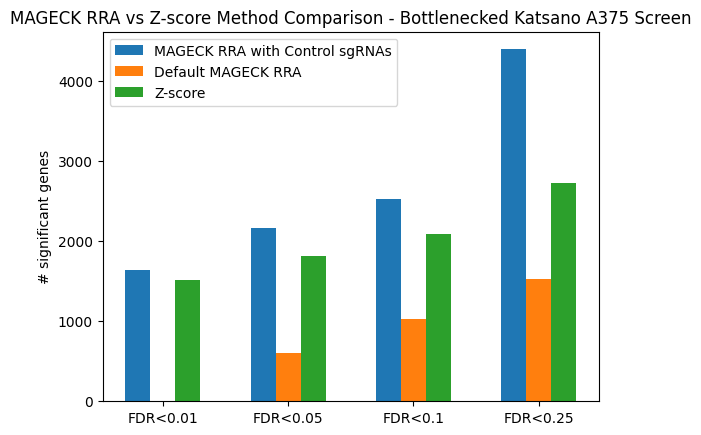

In [27]:
thresholds = [0.01, 0.05, 0.1, 0.25]
mageck_counts = [(mageck_results['fdr'] < t).sum() for t in thresholds]
mageck_with_controls_counts = [(mageck_with_controls_results['fdr'] < t).sum() for t in thresholds]
zscored_gene_lfcs_counts = [(zscored_gene_lfcs['FDR'] < t).sum() for t in thresholds]

x = np.arange(len(thresholds))
plt.bar(x-0.2, mageck_with_controls_counts, width=0.2, label='MAGECK RRA with Control sgRNAs')
plt.bar(x, mageck_counts, width=0.2, label='Default MAGECK RRA')
plt.bar(x + 0.2, zscored_gene_lfcs_counts, width=0.2, label='Z-score')
plt.xticks(x, [f'FDR<{t}' for t in thresholds])
plt.ylabel('# significant genes')
plt.title("MAGECK RRA vs Z-score Method Comparison - Bottlenecked Katsano A375 Screen")
plt.legend()
plt.savefig("output/bottlenecked_bar_plot.png", dpi=300, bbox_inches="tight")

## Comparison to full sample

### MAGeCK with full sample

MAGeCK was then run on pooled counts of A375_CP2240.

Full sample without controls:
mageck test -k data/pooled_counts-DG_GOL_CP2240_A375_K562.txt \
-t A375_CP2240_repA,A375_CP2240_repB \
-c pDNA_CP2240 \
-n MAGECK_output_full_sample/MAGECK_results

Full sample with controls: 

mageck test -k data/pooled_counts-DG_GOL_CP2240_A375_K562.txt \
-t A375_CP2240_repA,A375_CP2240_repB \
-c pDNA_CP2240 \
--control-sgrna control_mageck.txt \
-n MAGECK_output_full_sample_with_controls/MAGECK_results

In [28]:
mageck_full_default_results = pd.read_table('MAGECK_output_full_sample/MAGECK_results.gene_summary.txt')
mageck_full_default_results['fdr'] = mageck_full_default_results[['neg|fdr', 'pos|fdr']].min(axis=1)
mageck_full_default_results['-log10 FDR'] = -np.log10(mageck_full_default_results['fdr'].clip(lower=1e-10))

In [29]:
mageck_full_results_controls = pd.read_table('MAGECK_output_full_sample_with_controls//MAGECK_results.gene_summary.txt')
mageck_full_results_controls['fdr'] = mageck_full_results_controls[['neg|fdr', 'pos|fdr']].min(axis=1)
mageck_full_results_controls['-log10 FDR'] = -np.log10(mageck_full_results_controls['fdr'].clip(lower=1e-10))
mageck_full_results_controls

,id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,pos|score,pos|p-value,pos|fdr,pos|rank,pos|goodsgrna,pos|lfc,fdr,-log10 FDR
0,ENSG00000087191.14,6,1.527100e-10,2.462000e-07,0.000008,1,6,-6.4221,1.000000e+00,1.000000e+00,1.000000,20083,0,-6.4221,0.000008,5.096910
1,ENSG00000215472.10,6,1.057000e-08,2.462000e-07,0.000008,2,6,-4.7054,1.000000e+00,1.000000e+00,1.000000,20082,0,-4.7054,0.000008,5.096910
2,ENSG00000119616.11,5,2.372200e-08,2.462000e-07,0.000008,3,5,-7.9278,1.000000e+00,1.000000e+00,1.000000,20081,0,-7.9278,0.000008,5.096910
3,ENSG00000164338.10,5,7.692000e-08,2.462000e-07,0.000008,4,5,-5.1730,1.000000e+00,1.000000e+00,1.000000,20080,0,-5.1730,0.000008,5.096910
4,ENSG00000143374.18,3,1.152800e-07,2.462000e-07,0.000008,5,3,-8.1026,1.000000e+00,1.000000e+00,1.000000,20079,0,-8.1026,0.000008,5.096910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20078,ENSG00000150457.9,3,9.999500e-01,9.999500e-01,1.000000,20079,0,1.5830,5.098700e-05,1.937600e-04,0.344988,9,3,1.5830,0.344988,0.462196
20079,ENSG00000187642.10,3,9.999800e-01,9.999800e-01,1.000000,20080,0,1.4803,1.673900e-05,7.115000e-05,0.344988,4,3,1.4803,0.344988,0.462196
20080,ENSG00000160551.12,3,9.999900e-01,9.999800e-01,1.000000,20081,0,1.8540,1.404800e-05,6.819600e-05,0.344988,3,3,1.8540,0.344988,0.462196
20081,ENSG00000141510.19,3,1.000000e+00,1.000000e+00,1.000000,20082,0,1.9045,7.213900e-07,2.462000e-07,0.002475,2,3,1.9045,0.002475,2.606425


### Z-score Method with Full Sample

In [30]:
pooled_counts_df = pd.read_table('data/pooled_counts-DG_GOL_CP2240_A375_K562.txt')
pooled_counts_df = pooled_counts_df.drop(columns = {"K562_CP2240_repA", "K562_CP2240_repB", "Unlabeled Sample Barcodes"})
pooled_counts_df

,Construct Barcode,Construct IDs,A375_CP2240_repA,A375_CP2240_repB,pDNA_CP2240
0,ACATCTAGTCCATTCATAAA,ENSG00000186092.7,3019,1976,424
1,TACATCTAGTCCATTCATAA,ENSG00000186092.7,3846,3216,499
2,AATGAGATGGTTCTATTAGT,ENSG00000186092.7,2705,1245,312
3,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",2012,1468,323
4,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",1109,753,339
...,...,...,...,...,...
63399,GTATACACAGGGGTATATAC,ONE_INTERGENIC,1135,767,263
63400,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC,2812,1047,333
63401,GTATCATTGGGACTAATGGT,ONE_INTERGENIC,1100,479,231
63402,CATATATGGGGACTCAATGG,ONE_INTERGENIC,1406,2878,364


In [31]:
pooled_lognorm_df = pooled_counts_df.copy()
condition_columns = ['A375_CP2240_repA','A375_CP2240_repB', 'pDNA_CP2240']
pooled_lognorm_df[condition_columns] = pooled_lognorm_df[condition_columns].astype(float)
pooled_lognorm_df[condition_columns] = pooled_lognorm_df[condition_columns].apply(lognorm)
pooled_lognorm_df

,Construct Barcode,Construct IDs,A375_CP2240_repA,A375_CP2240_repB,pDNA_CP2240
0,ACATCTAGTCCATTCATAAA,ENSG00000186092.7,5.110318,4.514160,4.671337
1,TACATCTAGTCCATTCATAA,ENSG00000186092.7,5.450598,5.192293,4.897778
2,AATGAGATGGTTCTATTAGT,ENSG00000186092.7,4.956716,3.884325,4.249002
3,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",4.545631,4.107113,4.296404
4,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",3.735702,3.221362,4.362685
...,...,...,...,...,...
63399,GTATACACAGGGGTATATAC,ONE_INTERGENIC,3.766652,3.245113,4.016586
63400,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC,5.010915,3.652799,4.338185
63401,GTATCATTGGGACTAATGGT,ONE_INTERGENIC,3.724832,2.654614,3.841712
63402,CATATATGGGGACTCAATGG,ONE_INTERGENIC,4.054980,5.036719,4.460514


In [32]:
pooled_filtered_lognorms = pooled_lognorm_df.copy()
z_low = -3  # minimum z-score

# Z-score the pDNA columns
# z_scored_cols = [] # empty list to store new z score column names
pooled_filtered_lognorms['pDNA_z'] = (pooled_filtered_lognorms['pDNA_CP2240'] - pooled_filtered_lognorms['pDNA_CP2240'].mean())/pooled_filtered_lognorms['pDNA_CP2240'].std()

# Filter by z-score
pooled_filtered_lognorms = pooled_filtered_lognorms[pooled_filtered_lognorms['pDNA_z'] > z_low] # remove sgRNAs where pDNA z score is low 
# Drop z-scored columns
pooled_filtered_lognorms = pooled_filtered_lognorms.drop('pDNA_z', axis=1) # drop z score columns

In [33]:
print('Filtered ' + str(pooled_lognorm_df.shape[0] - pooled_filtered_lognorms.shape[0]) + ' sgRNAs with low pDNA')

Filtered 371 sgRNAs with low pDNA


In [34]:
target_col = ['A375_CP2240_repA','A375_CP2240_repB']
pooled_lfc_df = pooled_filtered_lognorms.copy()
for col in target_col:
    pooled_lfc_df[col] = pooled_filtered_lognorms[col] - pooled_filtered_lognorms['pDNA_CP2240'] # only one reference column
# drop reference column 
pooled_lfc_df = pooled_lfc_df.drop(columns = "pDNA_CP2240")
pooled_lfc_df

,Construct Barcode,Construct IDs,A375_CP2240_repA,A375_CP2240_repB
0,ACATCTAGTCCATTCATAAA,ENSG00000186092.7,0.438981,-0.157177
1,TACATCTAGTCCATTCATAA,ENSG00000186092.7,0.552820,0.294516
2,AATGAGATGGTTCTATTAGT,ENSG00000186092.7,0.707714,-0.364677
3,TCTGGGACTCACTCATTCAT,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",0.249228,-0.189290
4,GGATGGAGAGAATCACTCAG,"ENSG00000284733.2,ENSG00000284662.2,ENSG000002...",-0.626983,-1.141323
...,...,...,...,...
63399,GTATACACAGGGGTATATAC,ONE_INTERGENIC,-0.249934,-0.771474
63400,TCTGAATAGGGGCTACGATA,ONE_INTERGENIC,0.672730,-0.685387
63401,GTATCATTGGGACTAATGGT,ONE_INTERGENIC,-0.116880,-1.187098
63402,CATATATGGGGACTCAATGG,ONE_INTERGENIC,-0.405534,0.576205


In [35]:
pooled_lfc_df = pooled_lfc_df.drop(columns = 'Construct IDs')
pooled_long_lfcs = (pooled_lfc_df.melt(id_vars='Construct Barcode',
                         var_name='condition', value_name='lfc'))
pooled_long_lfcs

,Construct Barcode,condition,lfc
0,ACATCTAGTCCATTCATAAA,A375_CP2240_repA,0.438981
1,TACATCTAGTCCATTCATAA,A375_CP2240_repA,0.552820
2,AATGAGATGGTTCTATTAGT,A375_CP2240_repA,0.707714
3,TCTGGGACTCACTCATTCAT,A375_CP2240_repA,0.249228
4,GGATGGAGAGAATCACTCAG,A375_CP2240_repA,-0.626983
...,...,...,...
126061,GTATACACAGGGGTATATAC,A375_CP2240_repB,-0.771474
126062,TCTGAATAGGGGCTACGATA,A375_CP2240_repB,-0.685387
126063,GTATCATTGGGACTAATGGT,A375_CP2240_repB,-1.187098
126064,CATATATGGGGACTCAATGG,A375_CP2240_repB,0.576205


In [36]:
pooled_long_lfcs['condition'] = 'A375'
pooled_avg_lfcs = (pooled_long_lfcs.groupby(['Construct Barcode', 'condition'])
            .agg(avg_lfc = ('lfc', 'mean'),
                 n_obs = ('lfc', 'count'))
            .reset_index())
pooled_avg_lfcs

,Construct Barcode,condition,avg_lfc,n_obs
0,AAAAAAAAAAGTGACCTCCC,A375,0.997009,2
1,AAAAAAAAGGGAGAATCGAG,A375,0.012148,2
2,AAAAAAAGCCCAGGTTCAGA,A375,-0.269271,2
3,AAAAAAAGCTAAAGGTACTA,A375,0.917375,2
4,AAAAAAAGGGAGAATCGAGA,A375,0.035749,2
...,...,...,...,...
63028,TTTGTGTCCCCGCAGTGTCG,A375,-0.072653,2
63029,TTTGTGTGGAGCCCTCAAGG,A375,0.581015,2
63030,TTTGTGTGGTGCCCAGATAG,A375,-0.204629,2
63031,TTTGTTACAACAGCAATAAA,A375,0.369002,2


In [37]:
pooled_annotated_sgrna_lfcs = (pooled_avg_lfcs.merge(annotation_file.rename({'Target Sequence': 'Construct Barcode'}, axis=1),
                                       how='inner',
                                       on='Construct Barcode'))
pooled_annotated_sgrna_lfcs

,Construct Barcode,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision
0,AAAAAAAAAAGTGACCTCCC,A375,0.997009,2,ENSG00000243811,APOBEC3D,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1,AAAAAAAAGGGAGAATCGAG,A375,0.012148,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
2,AAAAAAAGCCCAGGTTCAGA,A375,-0.269271,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
3,AAAAAAAGCTAAAGGTACTA,A375,0.917375,2,ENSG00000173391,OLR1,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
4,AAAAAAAGGGAGAATCGAGA,A375,0.035749,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
...,...,...,...,...,...,...,...,...,...,...
63028,TTTGTGTCCCCGCAGTGTCG,A375,-0.072653,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
63029,TTTGTGTGGAGCCCTCAAGG,A375,0.581015,2,ENSG00000134594,RAB33A,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
63030,TTTGTGTGGTGCCCAGATAG,A375,-0.204629,2,ENSG00000177733,HNRNPA0,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
63031,TTTGTTACAACAGCAATAAA,A375,0.369002,2,ENSG00000186038,HTR3E,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict


In [38]:
# use guides with one intergenic site as controls
pooled_control_sgrna_lfcs = (pooled_annotated_sgrna_lfcs[(pooled_annotated_sgrna_lfcs['Notes']
                                            .str.contains('ONE_INTERGENIC_SITE', na=False))]
                      .reset_index(drop=True))
pooled_control_sgrna_lfcs

,Construct Barcode,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision
0,AAAACATGAATCCCCATACA,A375,-0.379646,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1,AAAACTTAGTGTATAAACCC,A375,0.183072,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
2,AAAAGGCATCTGACTGACTG,A375,0.664839,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
3,AAAATATAGGTGGAGTACAT,A375,-0.421148,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
4,AAACAGAGGTACTCTAACCC,A375,-1.161156,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
...,...,...,...,...,...,...,...,...,...,...
1333,TTGCTGCCTTGCCACTATGA,A375,0.764549,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1334,TTGGGCGTCCGAGCGGCTGT,A375,0.840516,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1335,TTGTTCGTAAGGCTACTATA,A375,0.444626,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict
1336,TTGTTGTAAGGATTGATCCA,A375,-0.287510,2,NaN,NaN,ONE_INTERGENIC_SITE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict


In [39]:
pooled_control_sgrna_stats = (pooled_control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('avg_lfc', 'mean'),
                            neg_ctl_sd = ('avg_lfc', 'std'))
                       .reset_index())
pooled_control_sgrna_stats

,condition,neg_ctl_mean,neg_ctl_sd
0,A375,-0.076093,0.668937


In [40]:
pooled_zscored_sgrna_lfcs = pooled_annotated_sgrna_lfcs.copy()
pooled_zscored_sgrna_lfcs = (pooled_zscored_sgrna_lfcs.merge(pooled_control_sgrna_stats,
                                               how='inner', on='condition'))
pooled_zscored_sgrna_lfcs['z_scored_avg_lfc'] = ((pooled_zscored_sgrna_lfcs['avg_lfc'] - pooled_zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          pooled_zscored_sgrna_lfcs['neg_ctl_sd'])
pooled_zscored_sgrna_lfcs = pooled_zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean'], axis=1)
pooled_zscored_sgrna_lfcs

,Construct Barcode,condition,avg_lfc,n_obs,On-target Gene IDs,On-target Gene Symbols,Notes,Reference DB,CRISPR System,Precision,z_scored_avg_lfc
0,AAAAAAAAAAGTGACCTCCC,A375,0.997009,2,ENSG00000243811,APOBEC3D,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,1.604189
1,AAAAAAAAGGGAGAATCGAG,A375,0.012148,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.131912
2,AAAAAAAGCCCAGGTTCAGA,A375,-0.269271,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,-0.288784
3,AAAAAAAGCTAAAGGTACTA,A375,0.917375,2,ENSG00000173391,OLR1,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,1.485143
4,AAAAAAAGGGAGAATCGAGA,A375,0.035749,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.167193
...,...,...,...,...,...,...,...,...,...,...,...
63028,TTTGTGTCCCCGCAGTGTCG,A375,-0.072653,2,NaN,NaN,POTENTIALLY_ACTIVE,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.005142
63029,TTTGTGTGGAGCCCTCAAGG,A375,0.581015,2,ENSG00000134594,RAB33A,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.982316
63030,TTTGTGTGGTGCCCAGATAG,A375,-0.204629,2,ENSG00000177733,HNRNPA0,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,-0.192149
63031,TTTGTTACAACAGCAATAAA,A375,0.369002,2,ENSG00000186038,HTR3E,NaN,Human - GRCh38 Ensembl,SpyoCas9 CRISPRi,strict,0.665376


In [41]:
pooled_zscored_gene_lfcs = (pooled_zscored_sgrna_lfcs.groupby(['On-target Gene IDs', 'condition'])
                     .agg(z_scored_lfc_sum = ('z_scored_avg_lfc', 'sum'), # sum of z_scored_avg_lfc per group
                          n_sgrnas = ('avg_lfc', 'count')) # count of avg_lfc = how many sgRNAs target that gene 
                     .reset_index())
pooled_zscored_gene_lfcs['z_scored_avg_lfc'] = (pooled_zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(pooled_zscored_gene_lfcs['n_sgrnas'])) # gene level z score
pooled_zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc
0,ENSG00000000003,A375,-7.454920,3,-4.304100
1,ENSG00000000005,A375,-0.171970,3,-0.099287
2,ENSG00000000419,A375,-4.375460,3,-2.526173
3,ENSG00000000457,A375,-0.327730,3,-0.189215
4,ENSG00000000460,A375,1.334402,3,0.770417
...,...,...,...,...,...
19006,"ENSG00000310603,ENSG00000243147",A375,-14.872455,3,-8.586616
19007,"ENSG00000310604,ENSG00000087338",A375,1.251790,3,0.722721
19008,"ENSG00000310607,ENSG00000172986",A375,-2.959030,3,-1.708397
19009,"ENSG00000310608,ENSG00000240230",A375,-15.569118,3,-8.988834


In [42]:
condition = pooled_zscored_gene_lfcs["condition"].iloc[0]

control_pseudogene_zscore_distribution_map = {
    condition: get_pseudogene_distribution(pooled_zscored_sgrna_lfcs, pooled_zscored_gene_lfcs)
}

pooled_zscored_gene_lfcs['pval'] = pooled_zscored_gene_lfcs['z_scored_avg_lfc'].apply(
    lambda z: get_empirical_gene_pval(z, condition)
)

pooled_zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval
0,ENSG00000000003,A375,-7.454920,3,-4.304100,7.049569e-03
1,ENSG00000000005,A375,-0.171970,3,-0.099287,8.804713e-01
2,ENSG00000000419,A375,-4.375460,3,-2.526173,9.171029e-02
3,ENSG00000000457,A375,-0.327730,3,-0.189215,8.169423e-01
4,ENSG00000000460,A375,1.334402,3,0.770417,4.773501e-01
...,...,...,...,...,...,...
19006,"ENSG00000310603,ENSG00000243147",A375,-14.872455,3,-8.586616,2.559354e-21
19007,"ENSG00000310604,ENSG00000087338",A375,1.251790,3,0.722721,5.076571e-01
19008,"ENSG00000310607,ENSG00000172986",A375,-2.959030,3,-1.708397,1.973311e-01
19009,"ENSG00000310608,ENSG00000240230",A375,-15.569118,3,-8.988834,7.714465e-27


In [43]:
pooled_zscored_gene_lfcs["FDR"]=pooled_zscored_gene_lfcs["pval"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
pooled_zscored_gene_lfcs["FDR"]= pooled_zscored_gene_lfcs["FDR"].explode().tolist()

In [44]:
pooled_zscored_gene_lfcs.loc[pooled_zscored_gene_lfcs["FDR"] < 0.001, "FDR"] = 0.001

In [45]:
pooled_zscored_gene_lfcs

,On-target Gene IDs,condition,z_scored_lfc_sum,n_sgrnas,z_scored_avg_lfc,pval,FDR
0,ENSG00000000003,A375,-7.454920,3,-4.304100,7.049569e-03,0.007050
1,ENSG00000000005,A375,-0.171970,3,-0.099287,8.804713e-01,0.880471
2,ENSG00000000419,A375,-4.375460,3,-2.526173,9.171029e-02,0.091710
3,ENSG00000000457,A375,-0.327730,3,-0.189215,8.169423e-01,0.816942
4,ENSG00000000460,A375,1.334402,3,0.770417,4.773501e-01,0.477350
...,...,...,...,...,...,...,...
19006,"ENSG00000310603,ENSG00000243147",A375,-14.872455,3,-8.586616,2.559354e-21,0.001000
19007,"ENSG00000310604,ENSG00000087338",A375,1.251790,3,0.722721,5.076571e-01,0.507657
19008,"ENSG00000310607,ENSG00000172986",A375,-2.959030,3,-1.708397,1.973311e-01,0.197331
19009,"ENSG00000310608,ENSG00000240230",A375,-15.569118,3,-8.988834,7.714465e-27,0.001000


In [46]:
sig_mageck_default    = set(mageck_results.loc[mageck_results['fdr'] < 0.05, 'id']
                             .str.split('.', n=1).str[0])
sig_mageck_ctrls      = set(mageck_with_controls_results.loc[mageck_with_controls_results['fdr'] < 0.05, 'id']
                             .str.split('.', n=1).str[0])
sig_zscore_bottleneck = set(zscored_gene_lfcs.loc[zscored_gene_lfcs['FDR'] < 0.05, 'On-target Gene IDs'])

sig_mageck_full_default = set(mageck_full_default_results.loc[mageck_full_default_results['fdr'] < 0.05, 'id']
                               .str.split('.', n=1).str[0])
sig_mageck_full_ctrls    = set(mageck_full_results_controls.loc[mageck_full_results_controls['fdr'] < 0.05, 'id']
                                .str.split('.', n=1).str[0])
sig_zscore_full          = set(pooled_zscored_gene_lfcs.loc[pooled_zscored_gene_lfcs['FDR'] < 0.05, 'On-target Gene IDs'])

def precision_recall_row(method_name, truth_name, hits, truth_hits):
    overlap = hits & truth_hits
    precision = len(overlap) / len(hits) if hits else float('nan')
    recall = len(overlap) / len(truth_hits) if truth_hits else float('nan')
    return {
        'Bottlenecked method': method_name,
        'Ground truth': truth_name,
        'Bottleneck hits': len(hits),
        'Ground truth hits': len(truth_hits),
        'Shared': len(overlap),
        'Precision': 'N/A (0 hits)' if not hits else f"{precision:.1%}",
        'Recall': 'N/A (0 hits)' if not truth_hits else f"{recall:.1%}",
    }

matched_pairs = [
    ('MAGeCK RRA (default)',            sig_mageck_default,    'Full-sample MAGeCK (default)',    sig_mageck_full_default),
    ('MAGeCK RRA (with control sgRNAs)', sig_mageck_ctrls,      'Full-sample MAGeCK (w/ controls)', sig_mageck_full_ctrls),
    ('Z-score (Drepanos et al.)',        sig_zscore_bottleneck, 'Full-sample Z-score',              sig_zscore_full),
]
matched_table = pd.DataFrame([precision_recall_row(m, t, h, th) for m, h, t, th in matched_pairs])
matched_table.to_excel('output/output_table.xlsx', index=False)

In [47]:
matched_table

,Bottlenecked method,Ground truth,Bottleneck hits,Ground truth hits,Shared,Precision,Recall
0,MAGeCK RRA (default),Full-sample MAGeCK (default),601,1114,535,89.0%,48.0%
1,MAGeCK RRA (with control sgRNAs),Full-sample MAGeCK (w/ controls),2166,2834,1979,91.4%,69.8%
2,Z-score (Drepanos et al.),Full-sample Z-score,1809,2909,1741,96.2%,59.8%


In [48]:
bottleneck_methods = {
    'MAGeCK RRA (default)':            sig_mageck_default,
    'MAGeCK RRA (with control sgRNAs)': sig_mageck_ctrls,
    'Z-score (Drepanos et al.)':        sig_zscore_bottleneck,
}
ground_truths = {
    'Full-sample MAGeCK (default)':     sig_mageck_full_default,
    'Full-sample MAGeCK (w/ controls)': sig_mageck_full_ctrls,
    'Full-sample Z-score':              sig_zscore_full,
}
cross_table = pd.DataFrame([
    precision_recall_row(m_name, t_name, hits, truth_hits)
    for m_name, hits in bottleneck_methods.items()
    for t_name, truth_hits in ground_truths.items()
])
cross_table

,Bottlenecked method,Ground truth,Bottleneck hits,Ground truth hits,Shared,Precision,Recall
0,MAGeCK RRA (default),Full-sample MAGeCK (default),601,1114,535,89.0%,48.0%
1,MAGeCK RRA (default),Full-sample MAGeCK (w/ controls),601,2834,601,100.0%,21.2%
2,MAGeCK RRA (default),Full-sample Z-score,601,2909,528,87.9%,18.2%
3,MAGeCK RRA (with control sgRNAs),Full-sample MAGeCK (default),2166,1114,1092,50.4%,98.0%
4,MAGeCK RRA (with control sgRNAs),Full-sample MAGeCK (w/ controls),2166,2834,1979,91.4%,69.8%
5,MAGeCK RRA (with control sgRNAs),Full-sample Z-score,2166,2909,1714,79.1%,58.9%
6,Z-score (Drepanos et al.),Full-sample MAGeCK (default),1809,1114,947,52.3%,85.0%
7,Z-score (Drepanos et al.),Full-sample MAGeCK (w/ controls),1809,2834,1529,84.5%,54.0%
8,Z-score (Drepanos et al.),Full-sample Z-score,1809,2909,1741,96.2%,59.8%
